# Emotion Detection: AI Essays vs Humanized Essays

This notebook uses the **RoBERTa-based GoEmotions** model from HuggingFace (`SamLowe/roberta-base-go_emotions`) to detect emotions in essays.

**Methodology:**
1. Load the dataset (`datasets.csv`) containing AI-generated and Humanized essays.
2. Use the GoEmotions model to predict the dominant emotions for each essay.
3. Compare emotion distributions between AI essays and Humanized essays.
4. Visualize the results.

In [1]:
# Install dependencies if needed (uncomment if first run)
!pip install transformers torch pandas matplotlib seaborn tqdm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load GoEmotions model from HuggingFace
print("Loading GoEmotions model (SamLowe/roberta-base-go_emotions)...")
emotion_classifier = pipeline(
    "text-classification", 
    model="SamLowe/roberta-base-go_emotions", 
    top_k=None,  # Return all emotion scores
    truncation=True
)
print("Model loaded successfully!")

/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.regi

Loading GoEmotions model (SamLowe/roberta-base-go_emotions)...
Model loaded successfully!
Model loaded successfully!


In [3]:
# Load dataset
dataset_path = '../datasets.csv'

df = pd.read_csv(dataset_path)
print(f"Dataset loaded. Shape: {df.shape}")
display(df.head(2))

Dataset loaded. Shape: (180, 6)


,topic,length,AI_model,humanizer,AI_essay,humanized_essay
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...


In [4]:
def get_emotions(text, max_length=512):
    """
    Get emotion predictions for a text.
    RoBERTa has a max token limit, so we truncate long texts.
    Returns dict of {emotion: score}
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}
    
    # Truncate to first ~2000 chars to avoid token limit issues
    text_truncated = text[:2000]
    
    try:
        results = emotion_classifier(text_truncated)
        # results is a list of list of dicts: [[{'label': 'neutral', 'score': 0.9}, ...]]
        emotions = {r['label']: r['score'] for r in results[0]}
        return emotions
    except Exception as e:
        print(f"Error processing text: {e}")
        return {}

def get_top_emotion(emotions_dict):
    """Get the emotion with highest score"""
    if not emotions_dict:
        return "unknown"
    return max(emotions_dict, key=emotions_dict.get)

def get_top_n_emotions(emotions_dict, n=3):
    """Get top N emotions as a list of tuples"""
    if not emotions_dict:
        return []
    sorted_emotions = sorted(emotions_dict.items(), key=lambda x: x[1], reverse=True)
    return sorted_emotions[:n]

print("Emotion extraction functions defined.")

Emotion extraction functions defined.


In [5]:
# Process all essays (This may take a while depending on dataset size)
# We'll process both AI_essay and humanized_essay columns

tqdm.pandas()

print("Analyzing AI Essays...")
df['AI_emotions'] = df['AI_essay'].progress_apply(get_emotions)
df['AI_top_emotion'] = df['AI_emotions'].apply(get_top_emotion)

print("\nAnalyzing Humanized Essays...")
df['Human_emotions'] = df['humanized_essay'].progress_apply(get_emotions)
df['Human_top_emotion'] = df['Human_emotions'].apply(get_top_emotion)

print("\nProcessing complete!")
display(df[['topic', 'humanizer', 'AI_top_emotion', 'Human_top_emotion']].head(10))

Analyzing AI Essays...


100%|██████████| 180/180 [00:30<00:00,  5.87it/s]



Analyzing Humanized Essays...


100%|██████████| 180/180 [00:25<00:00,  6.97it/s]


Processing complete!


,topic,humanizer,AI_top_emotion,Human_top_emotion
0,1,AIHumanizer,sadness,sadness
1,1,Grammarly,sadness,neutral
2,1,HumanizeAI,sadness,neutral
3,1,Quillbot,sadness,neutral
4,1,UndetectableAI,sadness,sadness
5,1,writehuman.ai,sadness,neutral
6,1,AIHumanizer,nervousness,nervousness
7,1,Grammarly,nervousness,nervousness
8,1,HumanizeAI,nervousness,fear
9,1,Quillbot,nervousness,nervousness


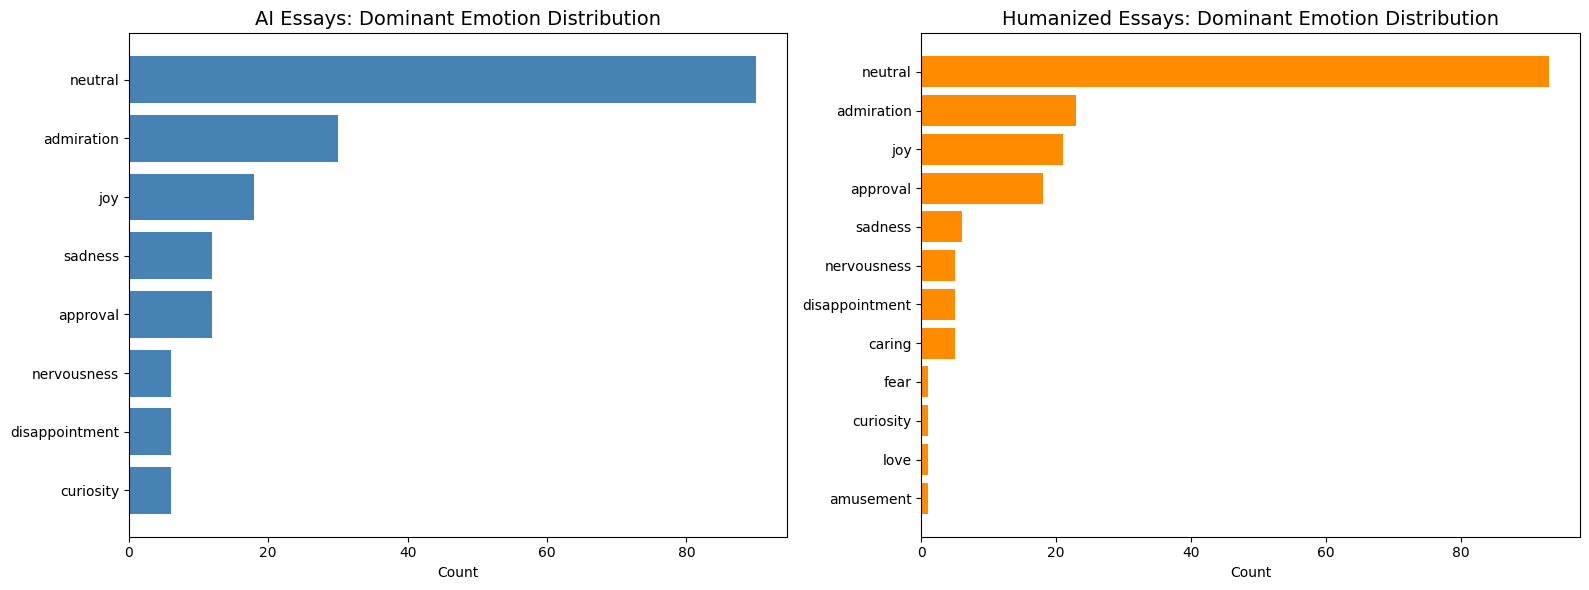

Key Insight: Compare which emotions dominate in AI vs Humanized essays.


In [6]:
# Visualization 1: Top Emotion Distribution Comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AI Essays - Top Emotion Distribution
ai_emotion_counts = df['AI_top_emotion'].value_counts()
axes[0].barh(ai_emotion_counts.index, ai_emotion_counts.values, color='steelblue')
axes[0].set_title('AI Essays: Dominant Emotion Distribution', fontsize=14)
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Humanized Essays - Top Emotion Distribution  
human_emotion_counts = df['Human_top_emotion'].value_counts()
axes[1].barh(human_emotion_counts.index, human_emotion_counts.values, color='darkorange')
axes[1].set_title('Humanized Essays: Dominant Emotion Distribution', fontsize=14)
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Key Insight: Compare which emotions dominate in AI vs Humanized essays.")

Showing 18 of 28 emotions (threshold: 0.01)


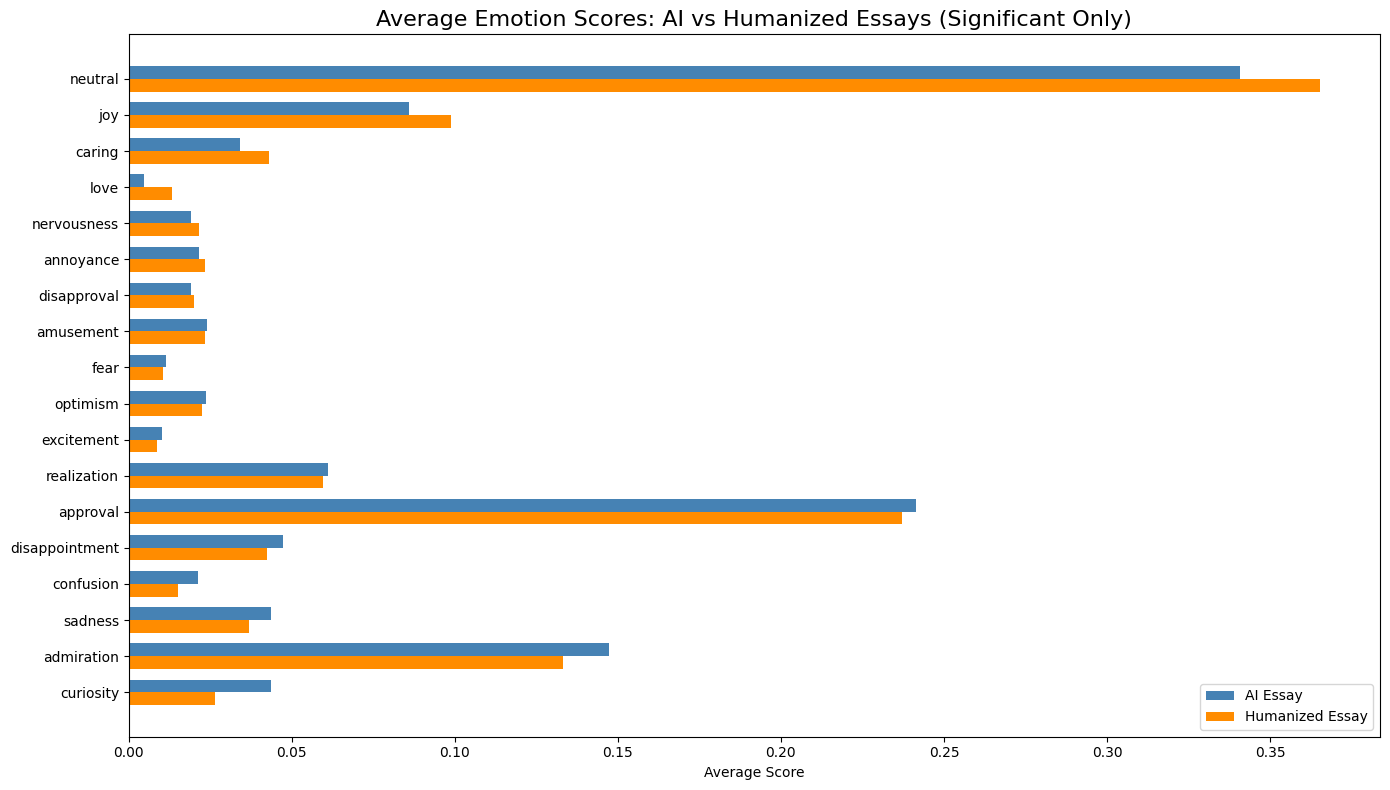


Top 5 Emotions with HIGHER scores in Humanized Essays:


,Emotion,AI Essay,Humanized Essay,Difference
2,neutral,0.340906,0.365467,0.024561
21,joy,0.086046,0.098708,0.012663
9,caring,0.033972,0.043020,0.009048
20,love,0.004533,0.013185,0.008651
6,nervousness,0.019077,0.021422,0.002345



Top 5 Emotions with LOWER scores in Humanized Essays:


,Emotion,AI Essay,Humanized Essay,Difference
1,disappointment,0.047406,0.042330,-0.005076
16,confusion,0.021166,0.015083,-0.006083
0,sadness,0.043474,0.036953,-0.006521
19,admiration,0.147273,0.133176,-0.014097
22,curiosity,0.043464,0.026291,-0.017174


In [12]:
# Visualization 2: Average Emotion Scores Comparison (Significant Emotions Only)

# Aggregate all emotion scores
all_emotions = list(df['AI_emotions'].iloc[0].keys()) if len(df) > 0 and df['AI_emotions'].iloc[0] else []

# Define significance threshold - only show emotions with avg score > 0.01 (1%)
SIGNIFICANCE_THRESHOLD = 0.01

if all_emotions:
    # Calculate mean scores for each emotion
    ai_mean_scores = {}
    human_mean_scores = {}
    
    for emotion in all_emotions:
        ai_mean_scores[emotion] = df['AI_emotions'].apply(lambda x: x.get(emotion, 0)).mean()
        human_mean_scores[emotion] = df['Human_emotions'].apply(lambda x: x.get(emotion, 0)).mean()
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Emotion': all_emotions,
        'AI Essay': [ai_mean_scores[e] for e in all_emotions],
        'Humanized Essay': [human_mean_scores[e] for e in all_emotions]
    })
    comparison_df['Difference'] = comparison_df['Humanized Essay'] - comparison_df['AI Essay']
    comparison_df['Max Score'] = comparison_df[['AI Essay', 'Humanized Essay']].max(axis=1)
    
    # Filter to only significant emotions (at least one score above threshold)
    significant_df = comparison_df[comparison_df['Max Score'] >= SIGNIFICANCE_THRESHOLD].copy()
    significant_df = significant_df.sort_values('Difference', ascending=False)
    
    print(f"Showing {len(significant_df)} of {len(comparison_df)} emotions (threshold: {SIGNIFICANCE_THRESHOLD})")
    
    # Plot
    plt.figure(figsize=(14, 8))
    
    x = np.arange(len(significant_df))
    width = 0.35
    
    plt.barh(x - width/2, significant_df['AI Essay'], width, label='AI Essay', color='steelblue')
    plt.barh(x + width/2, significant_df['Humanized Essay'], width, label='Humanized Essay', color='darkorange')
    
    plt.yticks(x, significant_df['Emotion'])
    plt.xlabel('Average Score')
    plt.title('Average Emotion Scores: AI vs Humanized Essays (Significant Only)', fontsize=16)
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Show top differences
    print("\nTop 5 Emotions with HIGHER scores in Humanized Essays:")
    display(significant_df.head(5)[['Emotion', 'AI Essay', 'Humanized Essay', 'Difference']])
    
    print("\nTop 5 Emotions with LOWER scores in Humanized Essays:")
    display(significant_df.tail(5)[['Emotion', 'AI Essay', 'Humanized Essay', 'Difference']])

Emotion Shift Rate: 36.7% of essays changed their dominant emotion after humanization


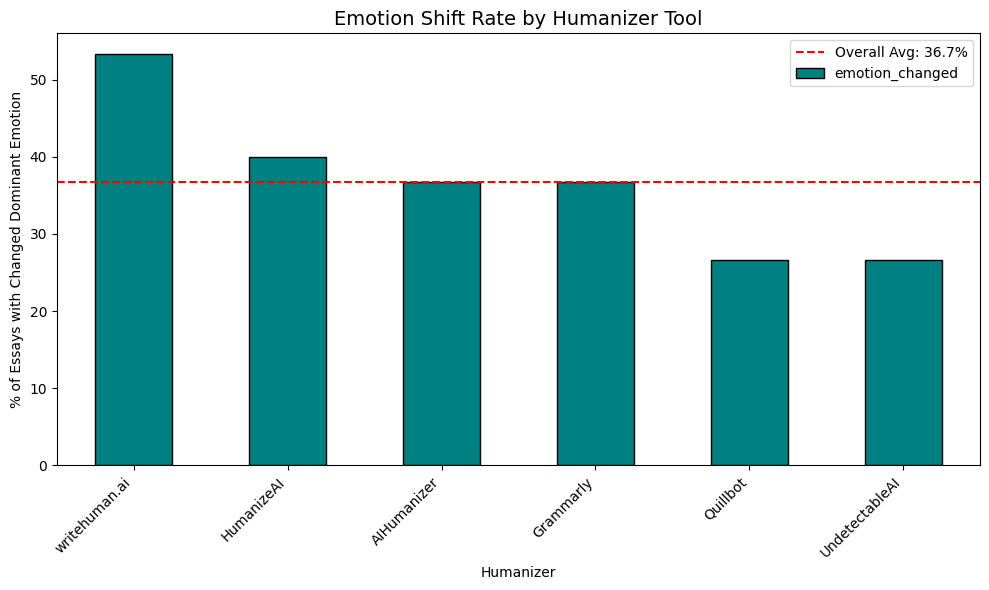

In [14]:
# Visualization 3: Emotion Shift Analysis (Did humanization change the emotion?)

df['emotion_changed'] = df['AI_top_emotion'] != df['Human_top_emotion']

change_rate = df['emotion_changed'].mean() * 100
print(f"Emotion Shift Rate: {change_rate:.1f}% of essays changed their dominant emotion after humanization")

# Breakdown by humanizer
shift_by_humanizer = df.groupby('humanizer')['emotion_changed'].mean() * 100
shift_by_humanizer = shift_by_humanizer.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
shift_by_humanizer.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Emotion Shift Rate by Humanizer Tool', fontsize=14)
plt.ylabel('% of Essays with Changed Dominant Emotion')
plt.xlabel('Humanizer')
plt.xticks(rotation=45, ha='right')
plt.axhline(change_rate, color='red', linestyle='--', label=f'Overall Avg: {change_rate:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

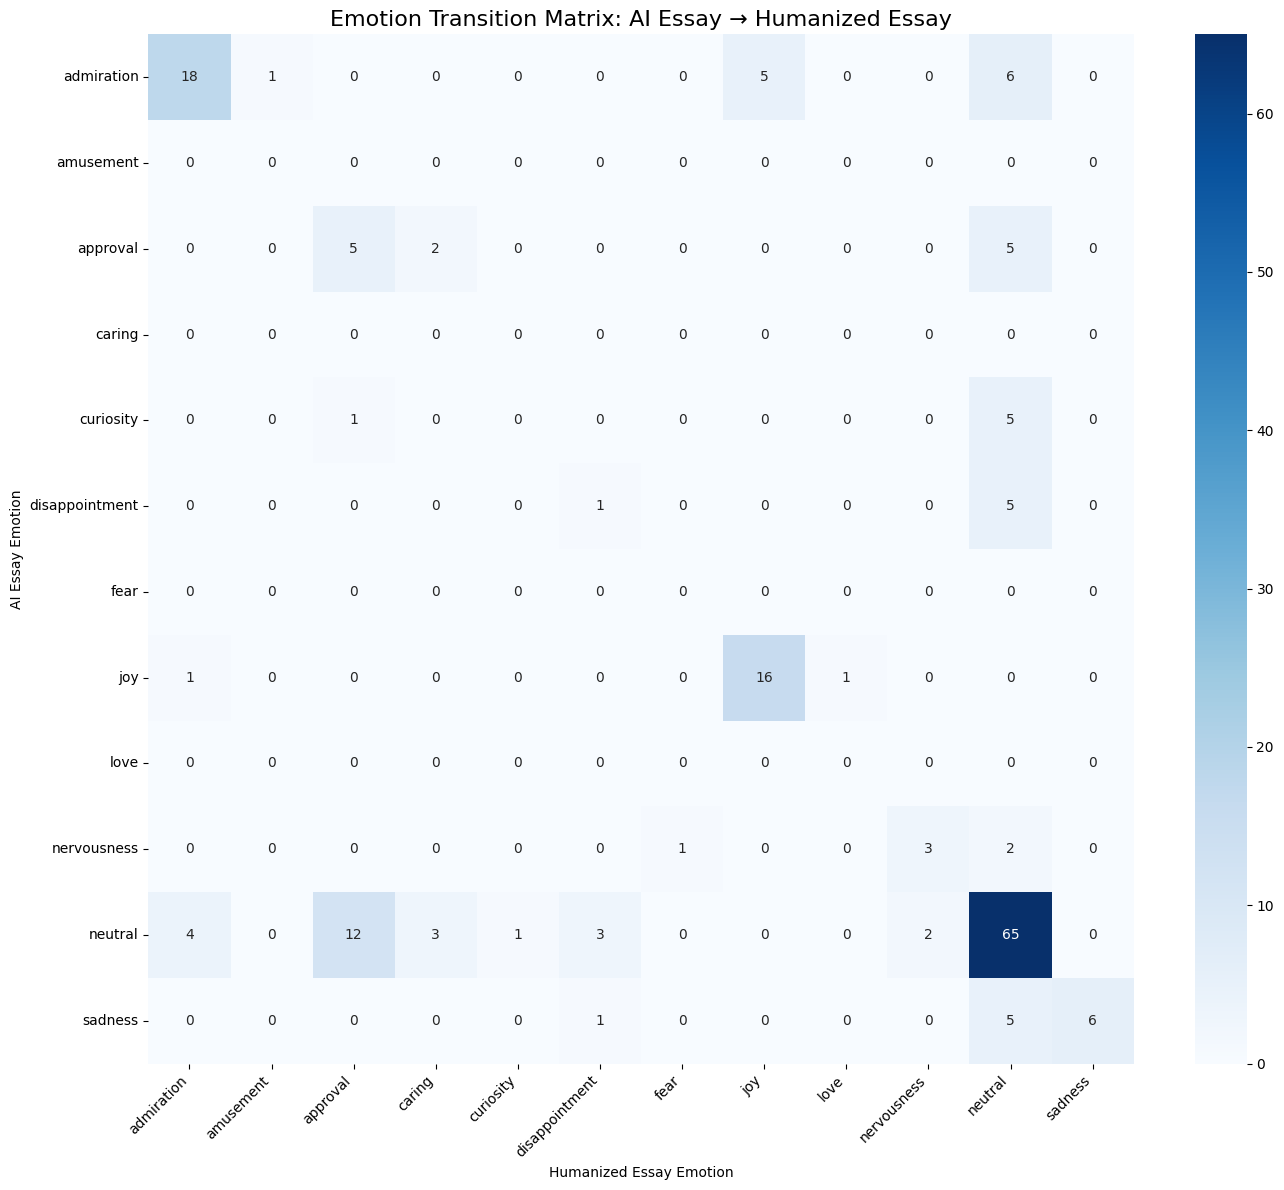

Interpretation:
- Diagonal = No change (same emotion before and after)
- Off-diagonal = Emotion shifted during humanization


In [15]:
# Visualization 4: Confusion Matrix - AI Emotion -> Humanized Emotion Transitions

from sklearn.metrics import confusion_matrix
import itertools

# Get unique emotions that appear in either column
all_top_emotions = list(set(df['AI_top_emotion'].unique()) | set(df['Human_top_emotion'].unique()))
all_top_emotions = sorted(all_top_emotions)

# Create confusion matrix
cm = confusion_matrix(df['AI_top_emotion'], df['Human_top_emotion'], labels=all_top_emotions)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=all_top_emotions, yticklabels=all_top_emotions)
plt.title('Emotion Transition Matrix: AI Essay → Humanized Essay', fontsize=16)
plt.xlabel('Humanized Essay Emotion')
plt.ylabel('AI Essay Emotion')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Diagonal = No change (same emotion before and after)")
print("- Off-diagonal = Emotion shifted during humanization")

Showing 9 of 28 emotions with |change| >= 0.005


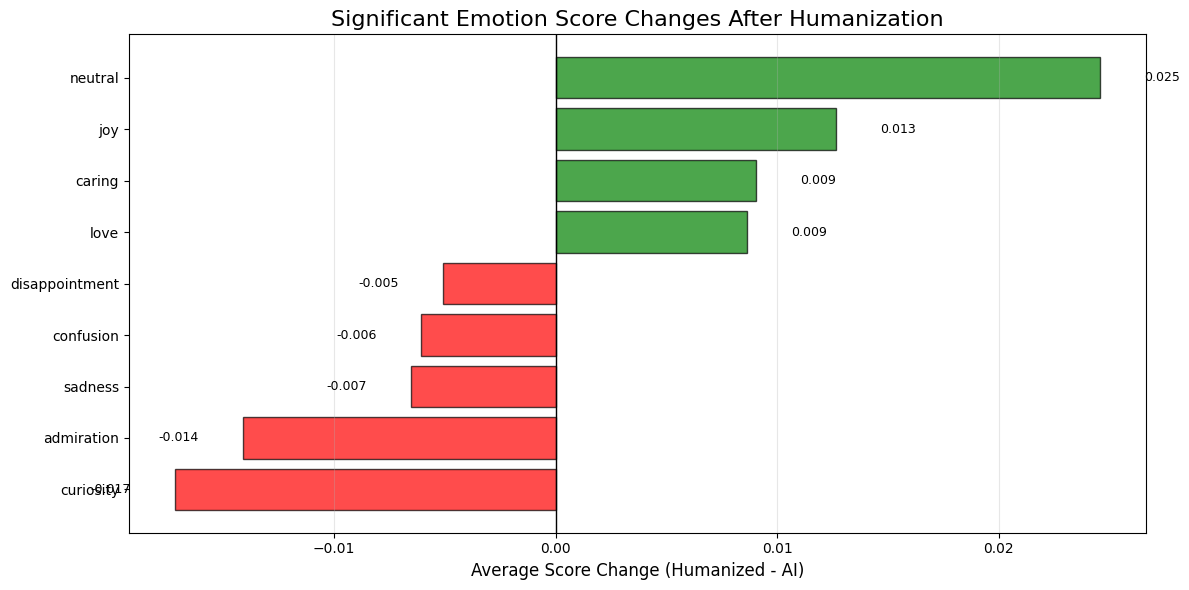


Interpretation:
- GREEN bars: Emotions that INCREASED after humanization
- RED bars: Emotions that DECREASED after humanization

Biggest Increase: neutral (+0.0246)
Biggest Decrease: curiosity (-0.0172)


In [16]:
# Visualization 5: Emotion Score Change Distribution (Significant Changes Only)

# Calculate the change in score for each emotion per essay
CHANGE_THRESHOLD = 0.005  # Only show emotions with |change| > 0.5%

if all_emotions:
    # Create a dataframe to hold the changes
    emotion_changes = pd.DataFrame()
    
    for emotion in all_emotions:
        ai_scores = df['AI_emotions'].apply(lambda x: x.get(emotion, 0))
        human_scores = df['Human_emotions'].apply(lambda x: x.get(emotion, 0))
        emotion_changes[emotion] = human_scores - ai_scores
    
    # Calculate mean change per emotion
    mean_changes = emotion_changes.mean().sort_values()
    
    # Filter to only significant changes
    significant_changes = mean_changes[abs(mean_changes) >= CHANGE_THRESHOLD]
    
    print(f"Showing {len(significant_changes)} of {len(mean_changes)} emotions with |change| >= {CHANGE_THRESHOLD}")
    
    # Plot: Waterfall-style bar chart showing avg change
    plt.figure(figsize=(12, 6))
    colors = ['green' if x > 0 else 'red' for x in significant_changes.values]
    
    plt.barh(significant_changes.index, significant_changes.values, color=colors, edgecolor='black', alpha=0.7)
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('Average Score Change (Humanized - AI)', fontsize=12)
    plt.title('Significant Emotion Score Changes After Humanization', fontsize=16)
    plt.grid(axis='x', alpha=0.3)
    
    # Add annotations for all significant changes
    for i, (emotion, change) in enumerate(significant_changes.items()):
        plt.text(change + 0.002 if change > 0 else change - 0.002, 
                 i, f'{change:.3f}', 
                 va='center', ha='left' if change > 0 else 'right', 
                 fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print("- GREEN bars: Emotions that INCREASED after humanization")
    print("- RED bars: Emotions that DECREASED after humanization")
    print(f"\nBiggest Increase: {mean_changes.idxmax()} (+{mean_changes.max():.4f})")
    print(f"Biggest Decrease: {mean_changes.idxmin()} ({mean_changes.min():.4f})")

Showing 12 of 28 emotions with significant changes


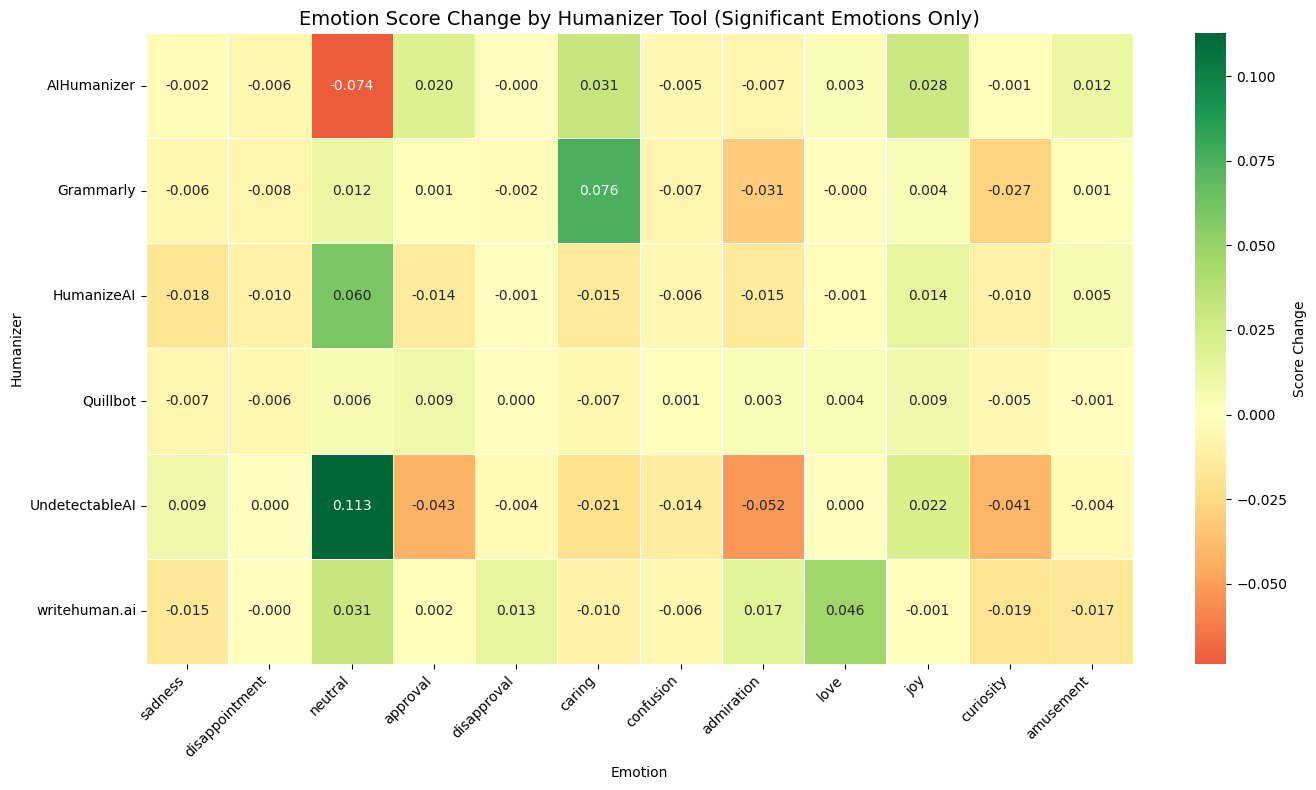


Interpretation:
- Green = Humanizer INCREASED this emotion
- Red = Humanizer DECREASED this emotion
- This shows which humanizers have the strongest emotional impact


In [17]:
# Visualization 6: Emotion Change by Humanizer (Heatmap - Significant Emotions Only)

if all_emotions:
    # Calculate mean change per emotion per humanizer
    humanizers = df['humanizer'].unique()
    
    change_by_humanizer = pd.DataFrame(index=humanizers, columns=all_emotions)
    
    for humanizer in humanizers:
        subset = df[df['humanizer'] == humanizer]
        for emotion in all_emotions:
            ai_scores = subset['AI_emotions'].apply(lambda x: x.get(emotion, 0))
            human_scores = subset['Human_emotions'].apply(lambda x: x.get(emotion, 0))
            change_by_humanizer.loc[humanizer, emotion] = (human_scores - ai_scores).mean()
    
    change_by_humanizer = change_by_humanizer.astype(float)
    
    # Filter: Only emotions where at least one humanizer has |change| > 0.01
    significant_emotions = change_by_humanizer.columns[change_by_humanizer.abs().max() >= 0.01].tolist()
    
    print(f"Showing {len(significant_emotions)} of {len(all_emotions)} emotions with significant changes")
    
    plt.figure(figsize=(14, 8))
    sns.heatmap(change_by_humanizer[significant_emotions], 
                cmap='RdYlGn', center=0, annot=True, fmt='.3f',
                linewidths=0.5, cbar_kws={'label': 'Score Change'})
    plt.title('Emotion Score Change by Humanizer Tool (Significant Emotions Only)', fontsize=14)
    plt.xlabel('Emotion')
    plt.ylabel('Humanizer')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print("- Green = Humanizer INCREASED this emotion")
    print("- Red = Humanizer DECREASED this emotion")
    print("- This shows which humanizers have the strongest emotional impact")

In [ ]:
# Save results to CSV for further analysis
output_df = df[['topic', 'length', 'AI_model', 'humanizer', 'AI_top_emotion', 'Human_top_emotion', 'emotion_changed']].copy()

# Add top 3 emotions as separate columns
output_df['AI_top3_emotions'] = df['AI_emotions'].apply(lambda x: get_top_n_emotions(x, 3))
output_df['Human_top3_emotions'] = df['Human_emotions'].apply(lambda x: get_top_n_emotions(x, 3))

output_df.to_csv('emotion_analysis_results.csv', index=False)
print("Results saved to 'emotion_analysis_results.csv'")
display(output_df.head())

In [2]:
import pandas as pd
df = pd.read_csv('emotion_chunked_results.csv')
df.head()

,topic,length,AI_model,humanizer,AI_intro_top,Human_intro_top,AI_body_top,Human_body_top,AI_conclusion_top,Human_conclusion_top,intro_shifted,body_shifted,conclusion_shifted
0,1,2,gemini2.5pro,AIHumanizer,neutral,realization,disappointment,neutral,neutral,neutral,True,True,False
1,1,2,gemini2.5pro,Grammarly,neutral,neutral,disappointment,neutral,neutral,disapproval,False,True,True
2,1,2,gemini2.5pro,HumanizeAI,neutral,neutral,disappointment,neutral,neutral,neutral,False,True,False
3,1,2,gemini2.5pro,Quillbot,neutral,neutral,disappointment,neutral,neutral,neutral,False,True,False
4,1,2,gemini2.5pro,UndetectableAI,neutral,approval,disappointment,neutral,neutral,neutral,True,True,False
